In [1]:
#Import libraries:

import xarray as xr #To read and work with netCDF files
import numpy as np #To work with arrays and perform numerical operations
import matplotlib.pyplot as plt #To create visualizations
import cartopy.crs as ccrs #To work with cartographic projections and create maps
from scipy.interpolate import griddata #To perform interpolation of data points onto a new grid
import requests #To make HTTP requests to access data from the I4C API
import sys
sys.path.append("..")
from utils.interpolation import Interpolator #To perform interpolation of data points onto a new grid 
                                                            #using the Interpolator class from the interpolation module 
                                                            # in the codigo_auxiliar_github package.
#interpolation.py was downloaded from 'https://github.com/ecmwf-projects/c3s-atlas/blob/main/c3s_atlas/interpolation.py'
import os #To save files in a directory

Functions

In [ ]:
def newlonlat_city_0(city_name):#Before taking an extra degree in each side.

    """
    It calculates the I4C reference longitude and latitude grid for a given city and gives the GitHub grid parameters as output.
    
    Parameters:
    city_name (str): The name of the city for which to calculate the grid.  The city options are: 'Paris', 'Barcelona', 'Prague', 'Bergen', 'Hamburg', 'NewCastle'.   
    
    Returns:
    longitude_2d (numpy.ndarray): A 2D array of longitudes for the I4C grid points.
    latitude_2d (numpy.ndarray): A 2D array of latitudes for the I4C grid points.
    xfirst (float): The first value of the x coordinate.
    xend (float): The last value of the x coordinate.
    xsize (int): The number of grid points in the x direction.
    ysize (int): The number of grid points in the y direction.
    xincrement (float): The spacing between consecutive x points.
    yincrement (float): The spacing between consecutive y points.
    yfirst (float): The first value of the y coordinate.
    yend (float): The last value of the y coordinate.
    """

    #Github repository with the grid variables for the interpolation:
    # url = "https://raw.githubusercontent.com/impetus4change/T32-CPRCM/refs/heads/main/grids-3i/ALPX-3i-Paris.grid"
    url="https://raw.githubusercontent.com/impetus4change/T32-CPRCM/refs/heads/main/grids-3i/ALPX-3i-"+city_name+".grid"

    #It downloads the content of the file (grid variables) as text
    text = requests.get(url).text

    #Create an empty dictionary:
    grid = {}

    for line in text.splitlines(): #Loops through the file line by line
                                    #text.splitlines() splits the full text into individual lines
        key, value = line.split("=")#Splits each line at the '=' symbol
        key = key.strip()#Removes extra spaces before and after the key
        value = value.strip()#Removes extra spaces before and after the value

        #The url content is read as text, here we convert the numbers of the varibles into float or interger
        try:
            value = float(value) if "." in value else int(value)
        except ValueError:#If the value isn´t a number, for example lonlat, it doesn´t do nothing
            pass

        grid[key] = value #Stores the result in the dictionary

    # Save grid variables individually
    grid_type = grid["gridtype"] #Gets the grid type
    x_size = grid["xsize"] #Gets the number of grid points in the x direction
    y_size = grid["ysize"]#Gets the number of grid points in the y direction
    x_first = grid["xfirst"]# Gets the first value of the x coordinate
    x_increment = grid["xinc"]# Gets the spacing between consecutive x points
    y_first = grid["yfirst"]# Gets the first value of the x coordinate
    y_increment = grid["yinc"]#Gets the spacing between consecutive y points

    longitude = x_first + np.arange(x_size) * x_increment #Creates the 1D longitude array in cartesian coordinates
                                                            # (x_first + [0, 1, 2, ..., last x] * x_increment)
    latitude = y_first + np.arange(y_size) * y_increment #Creates the 1D latitude array in cartesian coordinates
                                                        # (y_first + [0, 1, 2, ..., last y] * y_increment)

    # longitude_2d, latitude_2d = np.meshgrid(longitude, latitude) #Create 2D cordinates from the 1D arrays

    xend=x_first+(x_size)*x_increment
    yend=y_first+(y_size)*y_increment

    print(grid)
    # print(longitude_2d.shape, latitude_2d.shape)
    print(longitude.shape, latitude.shape)
    # return longitude_2d, latitude_2d, x_first, xend, x_size, y_size, x_increment, y_increment, y_first, yend
    return longitude, latitude, x_first, xend, x_size, y_size, x_increment, y_increment, y_first, yend

In [ ]:
def newlonlat_city(city_name):

    """
    It calculates the I4C reference longitude and latitude grid for a given city and gives the GitHub grid parameters as output.
    It's sum up one degree in each side of the 2D output grids to not lose data points in the interpolation.
    
    Parameters:
    city_name (str): The name of the city for which to calculate the grid.  The city options are: 'Paris', 'Barcelona', 'Prague', 'Bergen', 'Hamburg', 'NewCastle'.   
    
    Returns:
    longitude_2d (numpy.ndarray): A 2D array of longitudes for the I4C grid points.
    latitude_2d (numpy.ndarray): A 2D array of latitudes for the I4C grid points.
    xfirst (float): The first value of the x coordinate.
    xend (float): The last value of the x coordinate.
    xsize (int): The number of grid points in the x direction.
    ysize (int): The number of grid points in the y direction.
    xincrement (float): The spacing between consecutive x points.
    yincrement (float): The spacing between consecutive y points.
    yfirst (float): The first value of the y coordinate.
    yend (float): The last value of the y coordinate.
    """

    #Github repository with the grid variables for the interpolation:
    # url = "https://raw.githubusercontent.com/impetus4change/T32-CPRCM/refs/heads/main/grids-3i/ALPX-3i-Paris.grid"
    url="https://raw.githubusercontent.com/impetus4change/T32-CPRCM/refs/heads/main/grids-3i/ALPX-3i-"+city_name+".grid"

    #It downloads the content of the file (grid variables) as text
    text = requests.get(url).text

    #Create an empty dictionary:
    grid = {}

    for line in text.splitlines(): #Loops through the file line by line
                                    #text.splitlines() splits the full text into individual lines
        key, value = line.split("=")#Splits each line at the '=' symbol
        key = key.strip()#Removes extra spaces before and after the key
        value = value.strip()#Removes extra spaces before and after the value

        #The url content is read as text, here we convert the numbers of the varibles into float or interger
        try:
            value = float(value) if "." in value else int(value)
        except ValueError:#If the value isn´t a number, for example lonlat, it doesn´t do nothing
            pass

        grid[key] = value #Stores the result in the dictionary

    # Save grid variables individually
    grid_type = grid["gridtype"] #Gets the grid type
    x_size = grid["xsize"] #Gets the number of grid points in the x direction
    y_size = grid["ysize"]#Gets the number of grid points in the y direction
    x_first = grid["xfirst"]# Gets the first value of the x coordinate
    x_increment = grid["xinc"]# Gets the spacing between consecutive x points
    y_first = grid["yfirst"]# Gets the first value of the x coordinate
    y_increment = grid["yinc"]#Gets the spacing between consecutive y points

    #To not lose data points in the interpolation, the limits of the grid are expanded one degree in each side, so we sum up 1º 
    # to the first value and to the last value of the coordinates
    x_first_use=x_first-1
    y_first_use=y_first-1

    #Last value of the coordinates according to the GitHub grid parameters
    xend=x_first+(x_size-1)*x_increment
    yend=y_first+(y_size-1)*y_increment#We use (y_size - 1) because the first point is already y_first.

    #Expand the last value of the coordinates one degree
    x_end_use = xend + 1
    y_end_use = yend + 1


    ## Expand the size of the grid in each direction to keep the same spacing between points.
    x_size = round(((x_end_use) - (x_first_use)) / x_increment)
    y_size = round(((y_end_use) - (y_first_use)) / y_increment)#If the result is not an integer, it is rounded to the nearest integer, introducing a small error.

    longitude_expanded = (x_first_use) + np.arange(x_size) * x_increment #Creates the 1D longitude array in cartesian coordinates
                                                            # (x_first + [0, 1, 2, ..., last x] * x_increment)
                                                            #Limits are expanded one degree in each side to not lose data points in the interpolation
    latitude_expanded = (y_first_use) + np.arange(y_size) * y_increment #Creates the 1D latitude array in cartesian coordinates
                                                        # (y_first + [0, 1, 2, ..., last y] * y_increment)
                                                        #Limits are expanded one degree in each side to not lose data points in the interpolation

    # longitude_2d, latitude_2d = np.meshgrid(longitude, latitude) #Create 2D cordinates from the 1D arrays


    print(grid)
    # print(longitude_2d.shape, latitude_2d.shape)
    print(longitude_expanded.shape, latitude_expanded.shape)
    # return longitude_2d, latitude_2d, x_first, xend, x_size, y_size, x_increment, y_increment, y_first, yend
    return longitude_expanded, latitude_expanded, x_first, xend, x_size, y_size, x_increment, y_increment, y_first, yend


Global variables:

In [4]:
#Data path and file name:

file= 'ta1000_ALPX-3f_ERA5_evaluation_r1i1p1f1_BCCR-UCAN_WRF451R-CI4C_v1-r1_6hr_202301010000-202312311800.nc'
variable, domain, reanalisis, simulation_tipe, run_type1, runing_centre, model, run_type2, time_interval, time_period = file.split("_")
# print(variable, domain, reanalisis, simulation_tipe, run_type1, runing_centre, model, run_type2, time_interval, time_period)

# path='C:/Users/irene/PracticasUC/'#local path
# path='I4C_CPRM_DATA'+'/'+domain+'/'+runing_centre+'/'+reanalisis+'/'+reanalisis+'/'+simulation_tipe+'/'+run_type1+'/'+model+'/'+run_type2+'/'+time_interval+'/'+variable
path = '../utils/'#test path

# path_save='C:/Users/irene/PracticasUC/cropped_files/'#local path
# path_save='I4C_CPRM_CITY_DATA'+'/'+'Interpolated_data'+'/'+domain+'/'+runing_centre+'/'+reanalisis+'/'+reanalisis+'/'+simulation_tipe+'/'+run_type1+'/'+model+'/'+run_type2+'/'+time_interval+'/'+variable
path_save='../utils/'#test path

#City name
city_name='Paris'


Rest of the code

In [11]:
#Calculate the I4C grid for the city according the GitHub repository and save the grid parameters:
new_longitude, new_latitude, x_first, xend, x_size, y_size, x_increment, y_increment, y_first, yend = newlonlat_city(city_name)
#New_longitude and new_latitude already have the limits expanded

#Read the file and extract the variable :
ds = xr.open_dataset(path+file)
# T = ds[variable]

#Crop the dataset to the city area using the grid parameters obtained from the GitHub repository:
#It was ampliated the range 1º in each side to not lose data points in the interpolation below
city = ds.where((ds.lon >= (x_first-1)) & (ds.lon <= (xend+1)) &(ds.lat >= (y_first-1)) & (ds.lat <= (yend+1)),drop=True)

##Change coordinates from the model to the I4C grid:

#Original coordinates
lon_old = city["lon"].values
lat_old = city["lat"].values

#New coordinates: longitude_2d, latitude_2d (They were obtained  above)

#Conservative regridding of the data with the new coordinates:

#  prepare a dictionary for Interpolator class with the interpolation parameters:
int_attr = {
    "interpolation_method": "conservative_normed", #Regrid method to be used. Options are: 'nearest', 'linear', 'cubic', 'conservative_normed', 'conservative', 'splinef2d'.
    "lats": new_latitude,
    "lons": new_longitude,
    "var_name": variable #Indicates the name of the variable to be interpolated.
}
#Create an object with the necesary information to interpolate
interpolator = Interpolator(int_attr)
#Perform the interpolation
# city_interp = interpolator(city)
city_interp_0 = interpolator(city)
#Crop to the extra degree:
city_interp = city_interp_0.where((city_interp_0.lon >= x_first) & (city_interp_0.lon <= xend) &(city_interp_0.lat >= y_first) & (city_interp_0.lat <= yend),drop=True)





{'gridtype': 'lonlat', 'xsize': 89, 'ysize': 59, 'xfirst': 0.828125, 'xinc': 0.03125, 'yfirst': 47.921875, 'yinc': 0.03125}
(152,) (122,)


/nfs/home/gmeteo/moralesi/prueba_servidor/Y/envs/netcdf/lib/python3.14/site-packages/xesmf/smm.py:197: RuntimeWarning: invalid value encountered in cast
  outdata = outdata.astype(indata_dtype)


In [15]:
# city_interp_0

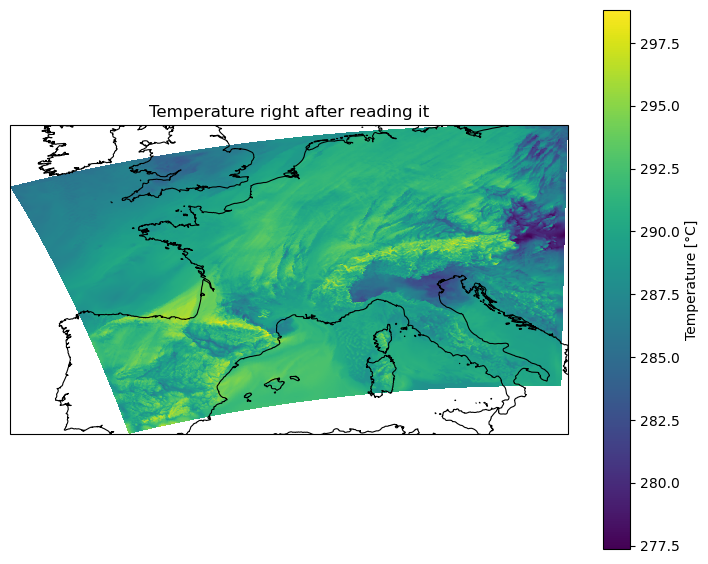

In [16]:
##Data right after reading it:

#Read the variable you want to visualize and select the first time to be able to represent it in a 2D map:
T = ds[variable].isel(time=0)

# Visualize the data with the silhouette of the continents using cartopy
fig = plt.figure(figsize=(9, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
m = ax.pcolormesh(ds["lon"],ds["lat"],T,shading="auto",transform=ccrs.PlateCarree())
ax.coastlines(resolution="10m", linewidth=0.8)
plt.colorbar(m, ax=ax, label="Temperature [°C]")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Temperature right after reading it")
plt.show()

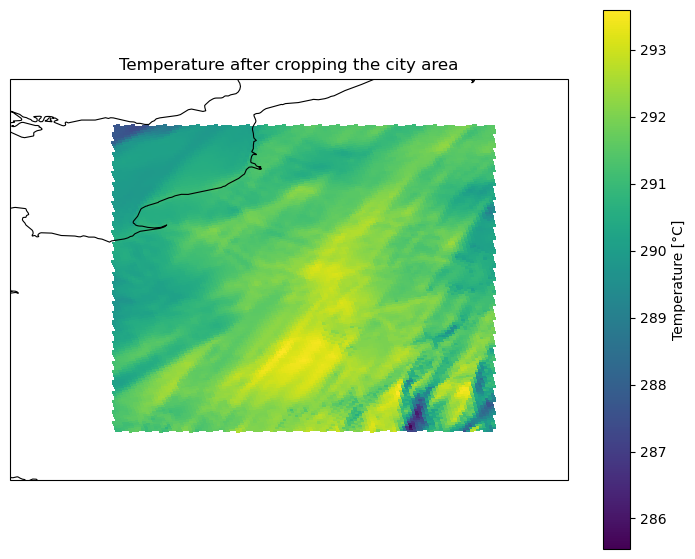

In [17]:
##Data after cropping the city area:

#Read the variable you want to visualize and select the first time to be able to represent it in a 2D map:
T2 = city[variable].isel(time=0)

# Visualize the data with the silhouette of the continents using cartopy
fig = plt.figure(figsize=(9, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
m = ax.pcolormesh(city["lon"],city["lat"],T2,shading="auto",transform=ccrs.PlateCarree())
ax.coastlines(resolution="10m", linewidth=0.8)
plt.colorbar(m, ax=ax, label="Temperature [°C]")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Temperature after cropping the city area")
plt.show()

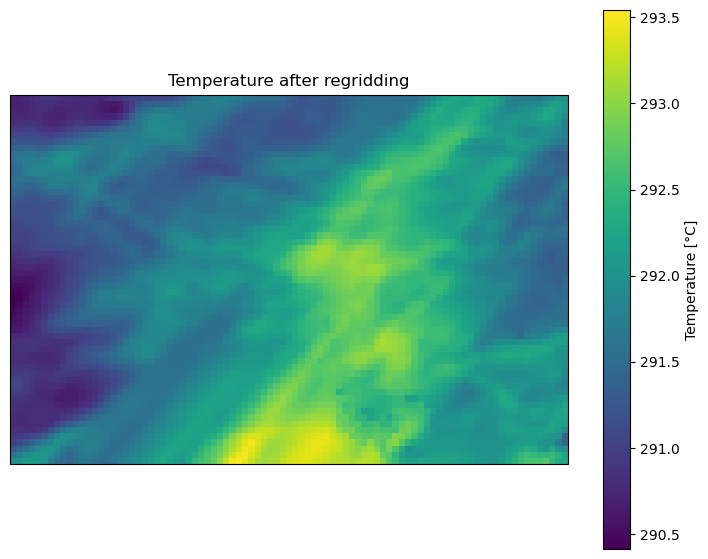

In [ ]:
##Data after regridding with conservative normed method:

#Read the variable you want to visualize and select the first time to be able to represent it in a 2D map:
T3= city_interp[variable].isel(time=0)

# Visualize the data with the silhouette of the continents using cartopy
fig = plt.figure(figsize=(9, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
m = ax.pcolormesh(city_interp["lon"],city_interp["lat"],T3,shading="auto",transform=ccrs.PlateCarree())
ax.coastlines(resolution="10m", linewidth=0.8)
plt.colorbar(m, ax=ax, label="Temperature [°C]")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Temperature after regridding")
plt.show()

In [20]:
# path#'../utils/'
# path_save#'../utils/'


In [19]:
# #Create a directory to save the results of the interpolation, with the name of it's characteristics:
# base_output_dir = path_save
# output_dir = f"{base_output_dir}/{variable}_{domain}_{reanalisis}_{simulation_tipe}_{run_type1}_{runing_centre}_{model}_{run_type2}_{time_interval}"
# os.makedirs(output_dir, exist_ok = True)

output_dir=path_save#test path

#Save the cropped and interpolated dataset (city_interp) as a new netCDF file in the above directory:
base_name = file.split(".")[0]#It takes the file name without the extension
city_interp.to_netcdf(output_dir+"/"+base_name+"_cropped_interpolated"+'.nc')